In [1]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load backgrounds separately

In [9]:
year = 2017
train,unnorm,mass,names = hf.LAPS_train("QCDBKG",year,num_batches=36,Mjj_cut=800,pt_cut=300,add_truth=True)

In [10]:
msk_qcd = train[:,-1] == 0
msk_singleTop = train[:,-1] == -1
msk_ttbar = train[:,-1] == -2
msk_vjets = train[:,-1] == -3

train = train[:,:-1] # don't need label any more
unnorm = unnorm[:,:-1]
names = names[:-1]

# take mean & std from background all together (for coherence in evaluating multi-dim on signal)
mean = np.mean(train,axis=0)
std = np.std(train,axis=0)

print("All bkgs : {0} events".format(train.shape[0]))

qcd = np.copy(train[msk_qcd])
qcd_unnnorm = np.copy(unnorm[msk_qcd])
qcd_mass = np.copy(mass[msk_qcd])
qcd = hf.normalize_data(qcd,inp_mean=mean,inp_std=std)
print("QCD : {0} events".format(qcd.shape[0]))

top = np.copy(train[msk_singleTop | msk_ttbar])
top_unnorm = np.copy(train[msk_singleTop | msk_ttbar])
top_mass = np.copy(mass[msk_singleTop | msk_ttbar])
top = hf.normalize_data(top,inp_mean=mean,inp_std=std)
print("top : {0} events".format(top.shape[0]))

vjets = np.copy(train[msk_vjets])
vjets_unnorm = np.copy(unnorm[msk_vjets])
vjets_mass = np.copy(mass[msk_vjets])
vjets = hf.normalize_data(vjets,inp_mean=mean,inp_std=std)
print("vjets : {0} events".format(vjets.shape[0]))

del train, unnorm, mass

All bkgs : 2088603 events
QCD : 2051885 events
top : 6480 events
vjets : 30238 events


In [11]:
with h5py.File("bkgMeanStds/QCDBKG_{0}.h5".format(year),"w") as f:
    f.create_dataset("mean",data=mean)
    f.create_dataset("std",data=std)

# Train on Bkgs Separately

In [12]:
train_params = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":120,"num_layers":6,"num_blocks_per_layer":4,
                "clip":10,"patience":20,"learning_rate":2e-5,"save_model":True,"bs":10000,"nmax":100000}

Initial: 100000 events 
Final: 99956 events 
Removed 0.0440%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Loss:  72.488655
Loss:  57.93401
Loss:  48.380432
Loss:  42.790794
Loss:  38.41358
Loss:  36.056225
Loss:  33.62951
Loss:  32.014603
Loss:  31.30977
Loss:  29.730423
Loss:  28.88733
Loss:  27.871313
Loss:  27.304283
Loss:  26.650003
Loss:  26.111208
Loss:  25.731918
Loss:  25.221832
Loss:  24.686054
Loss:  24.18832
Iteration 20 Complete
Loss:  24.011047
SAVING MODEL
Time:  25.41749334335327
------------------------------------
Loss:  23.549053
Loss:  23.13971
Loss:  22.896137
Loss:  22.511042
Loss:  22.396418
Loss:  22.039825
Loss:  21.8418
Loss:  21.521473
Loss:  21.309902
Loss:  21.087233
Loss:  20.686659
Loss:  20.49892
Loss:  20.336033
Loss:  20.13798
Loss:  19.852823
Loss:  19.501173
Loss:  19.433483
Loss:  19.145924
Loss:  19.0096
Iteration 40 Complete
Loss:  18.818153
SAVING MODEL
Time:  50.597975730895996
-------------------------------

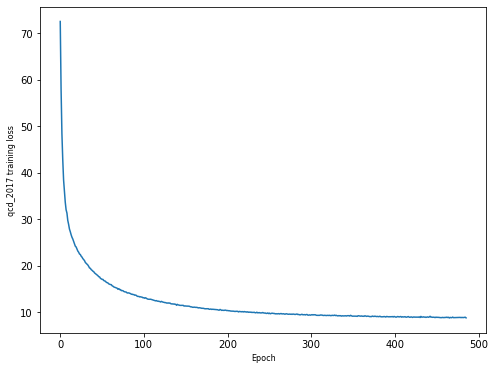

In [14]:
# train qcd
qcd_train = qcd[:100000]
qcd_test = qcd[100000:]
qcd_flow = hf.train_pipeline("qcd_{0}".format(year),qcd_train,names,train_params,pt_cut=300,Mjj_cut=800)

Initial: 5832 events 
Final: 5819 events 
Removed 0.2229%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Loss:  145.96347
Loss:  142.25815
Loss:  138.58083
Loss:  134.99518
Loss:  131.44862
Loss:  127.9703
Loss:  124.59846
Loss:  121.38085
Loss:  118.26152
Loss:  115.23964
Loss:  112.27189
Loss:  109.428764
Loss:  106.66357
Loss:  103.97887
Loss:  101.42099
Loss:  98.92052
Loss:  96.489044
Loss:  94.14432
Loss:  91.9116
Iteration 20 Complete
Loss:  89.777885
SAVING MODEL
Time:  3.3796417713165283
------------------------------------
Loss:  87.768555
Loss:  85.82224
Loss:  83.97168
Loss:  82.185585
Loss:  80.46742
Loss:  78.81981
Loss:  77.24351
Loss:  75.73582
Loss:  74.29665
Loss:  72.92506
Loss:  71.614944
Loss:  70.376724
Loss:  69.19059
Loss:  68.04703
Loss:  66.947044
Loss:  65.88707
Loss:  64.87042
Loss:  63.8886
Loss:  62.93695
Iteration 40 Complete
Loss:  62.019505
SAVING MODEL
Time:  6.653743267059326
------------------------------------
Los

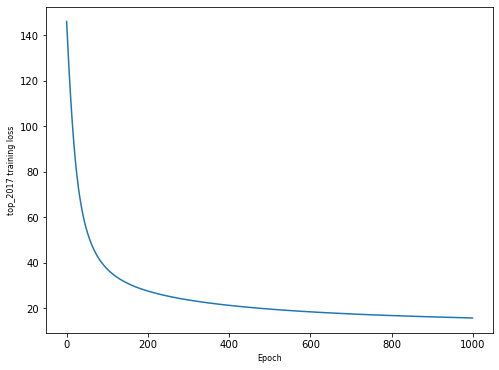

In [15]:
# train top
top_train = top[:int(0.9*top.shape[0])]
top_test = top[int(0.9*top.shape[0]):]
top_flow = hf.train_pipeline("top_{0}".format(year),top_train,names,train_params,pt_cut=300,Mjj_cut=800)

Initial: 27214 events 
Final: 27203 events 
Removed 0.0404%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Loss:  77.23995
Loss:  73.09099
Loss:  68.48164
Loss:  64.839096
Loss:  60.78718
Loss:  57.37792
Loss:  55.023674
Loss:  52.67419
Loss:  50.39469
Loss:  48.418457
Loss:  46.703823
Loss:  44.69034
Loss:  43.472874
Loss:  41.86798
Loss:  40.7796
Loss:  39.709705
Loss:  38.801975
Loss:  37.562523
Loss:  36.472275
Iteration 20 Complete
Loss:  35.831726
SAVING MODEL
Time:  8.405653238296509
------------------------------------
Loss:  35.085503
Loss:  34.63288
Loss:  33.789764
Loss:  33.03839
Loss:  32.728127
Loss:  32.093685
Loss:  31.385822
Loss:  30.948236
Loss:  30.63154
Loss:  30.034224
Loss:  29.612728
Loss:  29.198124
Loss:  28.969246
Loss:  28.668186
Loss:  28.413452
Loss:  27.676636
Loss:  27.605564
Loss:  27.34976
Loss:  27.201338
Iteration 40 Complete
Loss:  27.122416
SAVING MODEL
Time:  16.733739614486694
----------------------------------

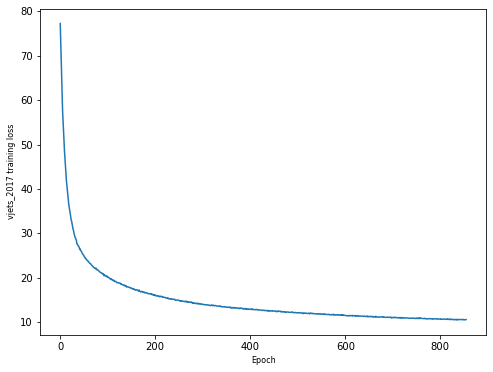

In [16]:
# train vjets
vjets_train = vjets[:int(0.9*vjets.shape[0])]
vjets_test = vjets[int(0.9*vjets.shape[0]):]
vjets_flow = hf.train_pipeline("vjets_{0}".format(year),vjets_train,names,train_params,pt_cut=300,Mjj_cut=800)

# Train on combined bkg

Initial: 58023 events 
Final: 57996 events 
Removed 0.0465%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Loss:  69.79584
Loss:  59.733494
Loss:  51.150593
Loss:  45.715485
Loss:  41.61126
Loss:  38.20829
Loss:  35.917942
Loss:  33.614407
Loss:  32.525475
Loss:  30.861557
Loss:  29.763378
Loss:  29.014688
Loss:  28.162584
Loss:  27.308971
Loss:  26.754213
Loss:  26.657278
Loss:  25.775839
Loss:  25.439917
Loss:  24.966835
Iteration 20 Complete
Loss:  24.759836
SAVING MODEL
Time:  15.680603981018066
------------------------------------
Loss:  24.368185
Loss:  24.000536
Loss:  23.887886
Loss:  23.48335
Loss:  23.255806
Loss:  22.956686
Loss:  22.758293
Loss:  22.582373
Loss:  22.195467
Loss:  22.23063
Loss:  21.814789
Loss:  21.682869
Loss:  21.542484
Loss:  21.548565
Loss:  21.281363
Loss:  20.96524
Loss:  20.992378
Loss:  20.924742
Loss:  20.625278
Iteration 40 Complete
Loss:  20.643763
NOT SAVING MODEL (PATIENCE = 1)
Time:  31.137993812561035
-----

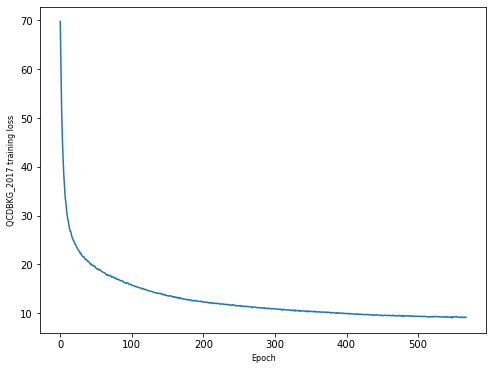

In [19]:
train_params = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":120,"num_layers":6,"num_blocks_per_layer":4,
                "clip":10,"patience":20,"learning_rate":2e-5,"save_model":True,"bs":10000,"nmax":100000}

with h5py.File("bkgMeanStds/QCDBKG_{0}.h5".format(year),"r") as f:
    mean = f["mean"][()]
    std = f["std"][()]

norm,unnorm,mass,varnames = hf.LAPS_train("QCDBKG",year,num_batches=1,Mjj_cut=800,pt_cut=300)
norm = hf.normalize_data(norm,inp_mean=mean,inp_std=std)

train = norm[:100000]
flow = hf.train_pipeline("QCDBKG_{0}".format(year),train,varnames,train_params,pt_cut=300,Mjj_cut=800)

# Density Estimation - combined background

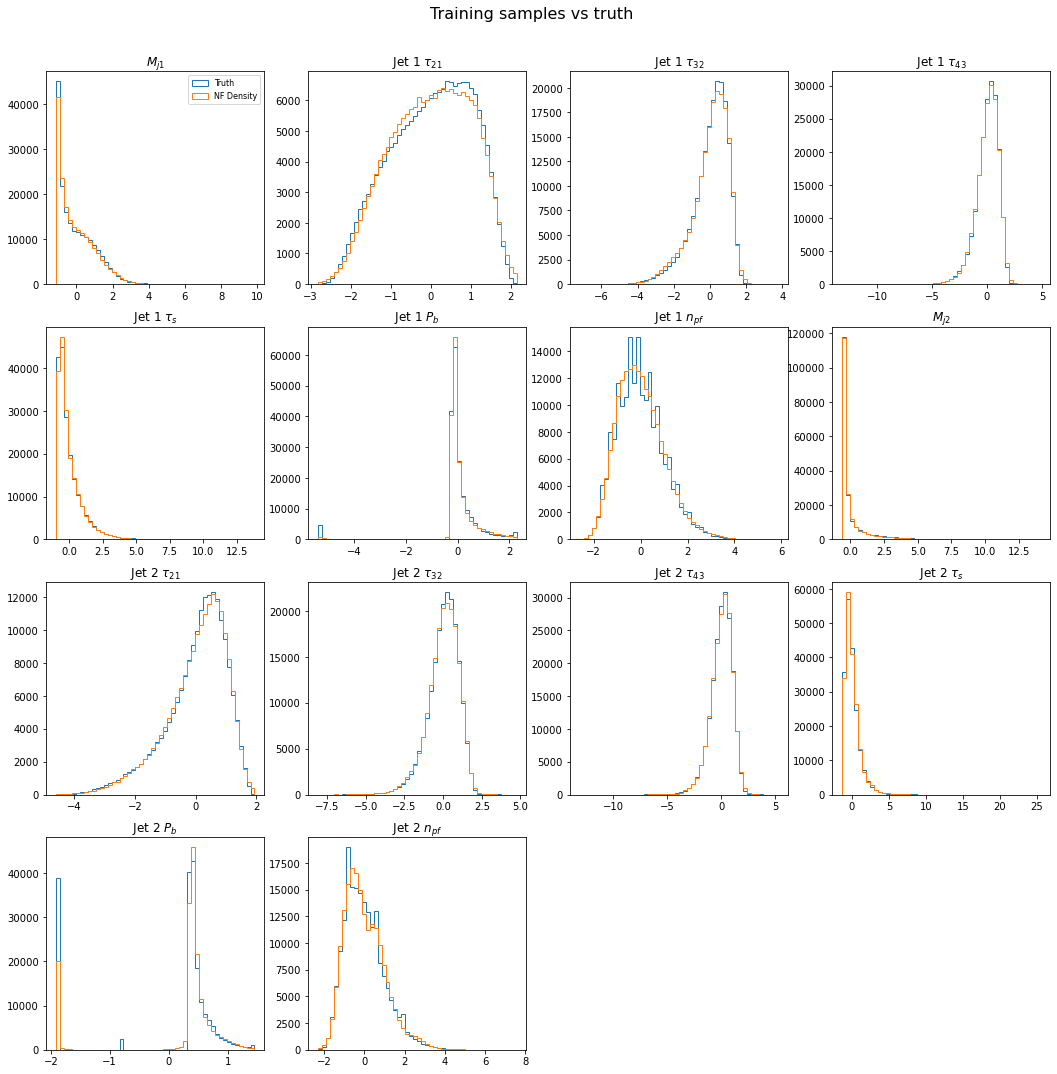

In [3]:
year=2017
with h5py.File("bkgMeanStds/QCDBKG_{0}.h5".format(year),"r") as f:
    mean = f["mean"][()]
    std = f["std"][()]

norm,unnorm,mass,varnames = hf.LAPS_train("QCDBKG",year,num_batches=5,Mjj_cut=800,pt_cut=300)
norm = hf.normalize_data(norm,inp_mean=mean,inp_std=std)

test = norm[100000:]
flow = hf.load_model(name="QCDBKG_2017_clip10_NSRATQUAD_k6_hf120_nbpl4_tb10_pt300.pt")
hf.plot_density_estimation(flow,test,varnames)